In [2]:
import pandas as pd
import re
import os
import google_conf
import gzip
import json
import nltk

In [3]:
metadata = pd.read_csv('/srv/data/jstor/jstor2026-04/jstor_metadata_2026-04-28-filtered.csv', low_memory=False)

In [4]:
mops_data = google_conf.setup(
    sheet_url="https://docs.google.com/spreadsheets/d/1VbCIAJssHKV9hlRTwzVFfm40CGnHesq53KXjv2qy4OM/edit?usp=sharing",
    service_account_path="../../../ServiceAccountsKey.json")

In [5]:
journals_annotated = google_conf.get_as_dataframe(mops_data.worksheet("journals_annotated"))
journals_annotated

,Journal,Background,Unnamed: 2,confession-codex,discipline-codex,Publisher,On behalf of,Other
0,Biblica,Catholic,NaN,Catholic,biblical/early Christian,Pontificial Biblical Institute,Pontificial Biblical Institute,NaN
1,The Catholic Biblical Quarterly,Catholic,NaN,Catholic,biblical/early Christian,The Catholic Biblical Association of America,The Catholic Biblical Association of America,NaN
2,Revue Biblique (1946-),Catholic,NaN,Catholic,biblical/early Christian,Peeters Publishers,École Biblique et Archéologique Française de J...,NaN
3,The Journal of Theological Studies,Protestant,NaN,Protestant,biblical/early Christian,Oxford University Press,NaN,"Anglican, protestant background historically"
4,Interpretation: A Journal of Bible and Theology,Protestant,NaN,Protestant,biblical/early Christian,SAGE Publications,Union Presbyterian Seminary,NaN
...,...,...,...,...,...,...,...,...
78,Theology,Protestant,NaN,Protestant,theology,SAGE Publications,Society for the Promotion of Christian Knowledge,SPCK is Anglican
79,Theology Today,Protestant,NaN,Protestant,theology,SAGE Publications,Princeton Theological Seminary,NaN
80,Scottish Journal of Theology,Protestant,NaN,Protestant,theology,Cambridge University Press,NaN,CUP since 2022
81,Review & Expositor: An International Baptist J...,Protestant,NaN,Protestant,theology,SAGE Publications,"Review & Expositor, Inc.",NaN


In [6]:
hits = pd.read_parquet("../data/large_files/paul_scan/hits.parquet", engine="pyarrow")

In [7]:
hits[hits["pattern"] == "A6_saint_paul"].sample(10)

,item_id,year,bidecade,journal,language,tier,pattern,flags,char_start,char_end,match,kwic_left,kwic_right,sentence,doc_len
317382,bf368cad-e7dc-328c-b19a-4a1b9c6da0f5,1996,1980-1999,Bulletin de la Société de l'Histoire du Protes...,fre,A,A6_saint_paul,None,62398,62405,S. Paul,…chose. Mais voyons (f° 10) pourquoy Dieu exau...,) il prie jouxte la volunté de Dieu pour les s...,S. Paul) il prie jouxte la volunté de Dieu pou...,70152
1130,00572541-951c-3a7f-b4cb-b5af151e39f3,1953,1940-1959,CrossCurrents,eng,A,A6_saint_paul,capital_after,15901,15909,St. Paul,"…to know, for what we know, is, and, what is, ...","All is good that God has made, nothing is to b...",The Catholic intellectual says with St. Paul A...,16123
359297,d6f8f393-d152-3795-94b2-a59f9aebb4db,2009,2000-2019,Church History,eng,A,A6_saint_paul,None,40698,40717,St. Vincent de Paul,…and architecture. Ozanam was a friend of Mont...,", a religious order devoted to serving the poo...",Ozanam was a friend of Montalembert and was al...,69404
267974,a2f78311-04d4-3d17-9d64-fe6114e43aa0,1930,1920-1939,Revue des Sciences philosophiques et théologiques,fre,A,A6_saint_paul,None,11948,11955,s. Paul,…spécialement de la fidélité de Dieu. Déjà les...,qu'il était réservé de lui donner une solution...,Déjà les évangélistes s'en montrent préoccupés...,30767
407735,f42008af-d653-32ca-a33a-356749b29fbb,1953,1940-1959,The Catholic Biblical Quarterly,eng,A,A6_saint_paul,place_or_building,410,418,St. Paul,…all the active members visiting Ottawa had th...,"'s Seminary of the University of Ottawa, where...",Almost all the active members visiting Ottawa ...,22484
407697,f41f9b61-b446-3bb6-9f0b-ccfcfb52aca6,2021,2020-2039,Revue d'histoire du protestantisme,fre,A,A6_saint_paul,None,72099,72106,S. Paul,…tous ceux qui abandonnent la bonne conscience...,", il nous l'a baillée, afin que nous ne soyons...","C'est la régie de S. Paul, il nous l'a baillée...",91628
84367,33f493bf-3ca0-3612-b16a-3aefe5a8c5ba,1974,1960-1979,The Harvard Theological Review,eng,A,A6_saint_paul,None,31788,31795,S. Paul,…Discipline of Divorce to the same Biblical pa...,", he cannot deny himselfe, that is, cannot den...","This Law, therefore, we may name eternal, bein...",43727
59196,23628189-27c1-3a78-b3f9-bea50386712b,1910,1900-1919,The American Journal of Theology,eng,A,A6_saint_paul,None,9166,9174,St. Paul,"…the doctrine of the union of Christ 6 Bacon, ...",", the Man and His Work, 301. o Op. cit., I, 32...","Meyer, Jesus or Paul 7 44. s St. Paul, the Man...",49879
136764,540a79a2-520c-32bd-a453-377b0c5396f7,1912,1900-1919,The Biblical World,eng,A,A6_saint_paul,capital_after,7535,7543,St. Paul,…are the headquarters of various student relig...,"Society for the Episcopalians, the Catholic Cl...",Here are the headquarters of various student r...,9659
395054,ecb8836d-a9a2-39fb-a8ec-ac59bc640c13,1991,1980-1999,Studies: An Irish Quarterly Review,eng,A,A6_saint_paul,capital_after,10683,10701,St Vincent de Paul,…demning the situation and calling for reform....,"Society and Catholic journeymen's clubs, he be...","Involved in many Catholic organizations, such ...",22675


In [8]:
hits["pattern"].value_counts()

pattern
C1_paul_then_lowercase       105682
C4_the_paul                   61057
A6_saint_paul                 52207
B3_of_paul                    50474
B2_paulus                     49617
B1_pauline_adj                39957
C2_paul_possessive            25372
A5_pauline_writings           17178
C3_paul_verb                   9885
B4_paul_genitive_abstract      7721
A1_apostle_pre                 3179
A3_apostle_foreign             2885
A2_apostle_post                1245
A4_tarsus                       458
Name: count, dtype: int64

### Exploring kwic token frequencies by journal categories and bidecades

In [9]:
_token_re = re.compile(r"\w+", flags=re.UNICODE)

hits["kwic_tokens"] = [
    _token_re.findall(f"{l} {r}")
    for l, r in zip(hits["kwic_left"].fillna(""), hits["kwic_right"].fillna(""))
]

In [10]:
journals_annotated["confession+discipline"] = journals_annotated["confession-codex"] + "+" + journals_annotated["discipline-codex"]

In [11]:
journals_cats_dict =    dict(zip(journals_annotated["Journal"], journals_annotated["confession+discipline"]))

In [12]:
journals_confessions_dict =    dict(zip(journals_annotated["Journal"], journals_annotated["confession-codex"]))
journals_disciplines_dict =    dict(zip(journals_annotated["Journal"], journals_annotated["discipline-codex"]))

In [13]:
hits["journal-cat"] = hits["journal"].map(journals_cats_dict)
hits["journal-discipline"] = hits["journal"].map(journals_disciplines_dict)
hits["journal-confession"] = hits["journal"].map(journals_confessions_dict)

In [14]:
hits.groupby("journal-confession").size().sort_values(ascending=False)

journal-confession
Protestant                        153495
Catholic                          105151
Independent/non-denominational     14284
Uncertain                           4031
Latter-day Saint                     313
dtype: int64

In [15]:
hits.groupby("journal-discipline").size().sort_values(ascending=False)

journal-discipline
biblical/early Christian    167002
theology                     75108
religion/culture             17273
religious history            12764
philosophy/ethics             5127
dtype: int64

In [16]:
hits.groupby("journal-cat").size().sort_values(ascending=False)

journal-cat
Protestant+biblical/early Christian                        93375
Catholic+biblical/early Christian                          67025
Protestant+theology                                        47706
Catholic+theology                                          27402
Catholic+religious history                                  7560
Independent/non-denominational+biblical/early Christian     6602
Protestant+religion/culture                                 6220
Independent/non-denominational+religion/culture             4147
Protestant+religious history                                3755
Uncertain+religion/culture                                  3429
Catholic+religion/culture                                   3164
Independent/non-denominational+philosophy/ethics            2688
Protestant+philosophy/ethics                                2439
Independent/non-denominational+religious history             847
Uncertain+religious history                                  602
Latter-day Sa

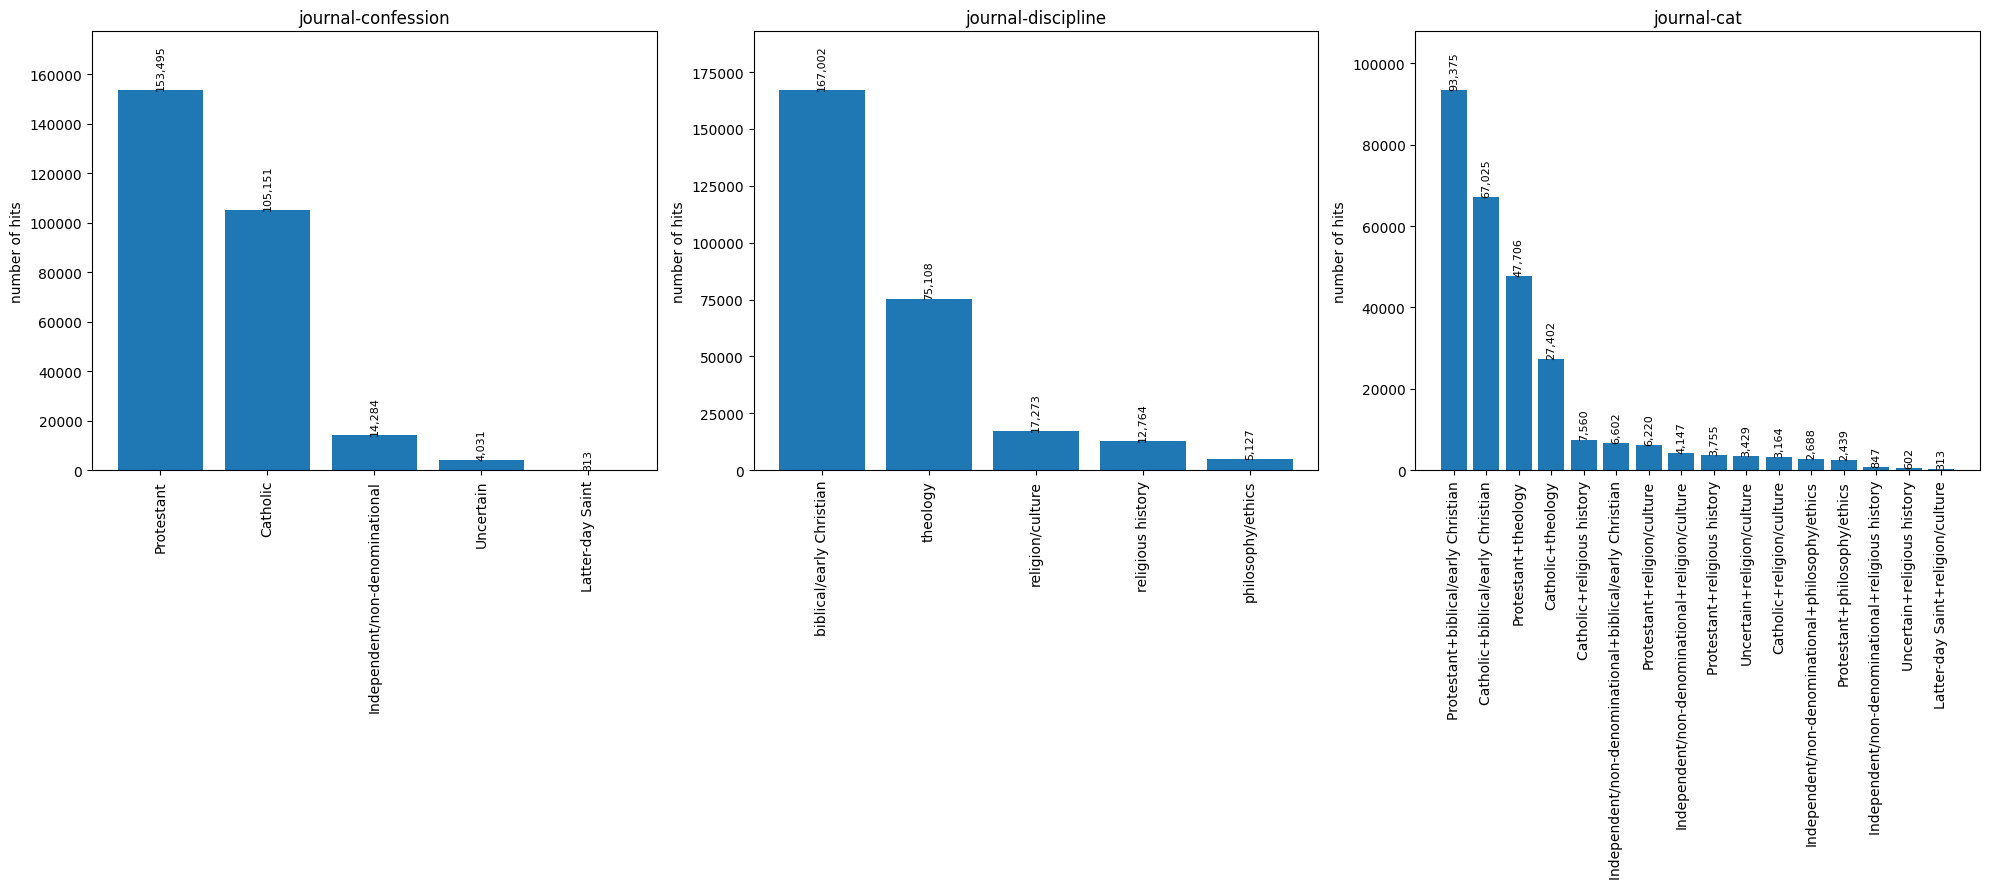

<Figure size 640x480 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt

groupings = ["journal-confession", "journal-discipline", "journal-cat"]

fig, axes = plt.subplots(1, 3, figsize=(20, 9))

for ax, col in zip(axes, groupings):
    counts = hits[col].dropna().value_counts().sort_values(ascending=False)  # descending → largest on the left
    ax.bar(counts.index, counts.values)
    ax.set_title(col)
    ax.set_ylabel("number of hits")
    ax.tick_params(axis="x", rotation=90)
    # annotate each bar with its value
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, rotation=90)
    # increase the ylim by 10% for headroom
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.1)

plt.tight_layout()
plt.show()

for ax, col in zip(axes, groupings):
    counts = hits[col].dropna().value_counts().sort_values(ascending=False)  # descending → largest on the left
    ax.bar(counts.index, counts.values)
    ax.set_title(col)
    ax.set_ylabel("number of hits")
    ax.tick_params(axis="x", rotation=90)
    # annotate each bar with its value
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

In [18]:
fig.savefig("../figures/hits-by-journal-groups.png")

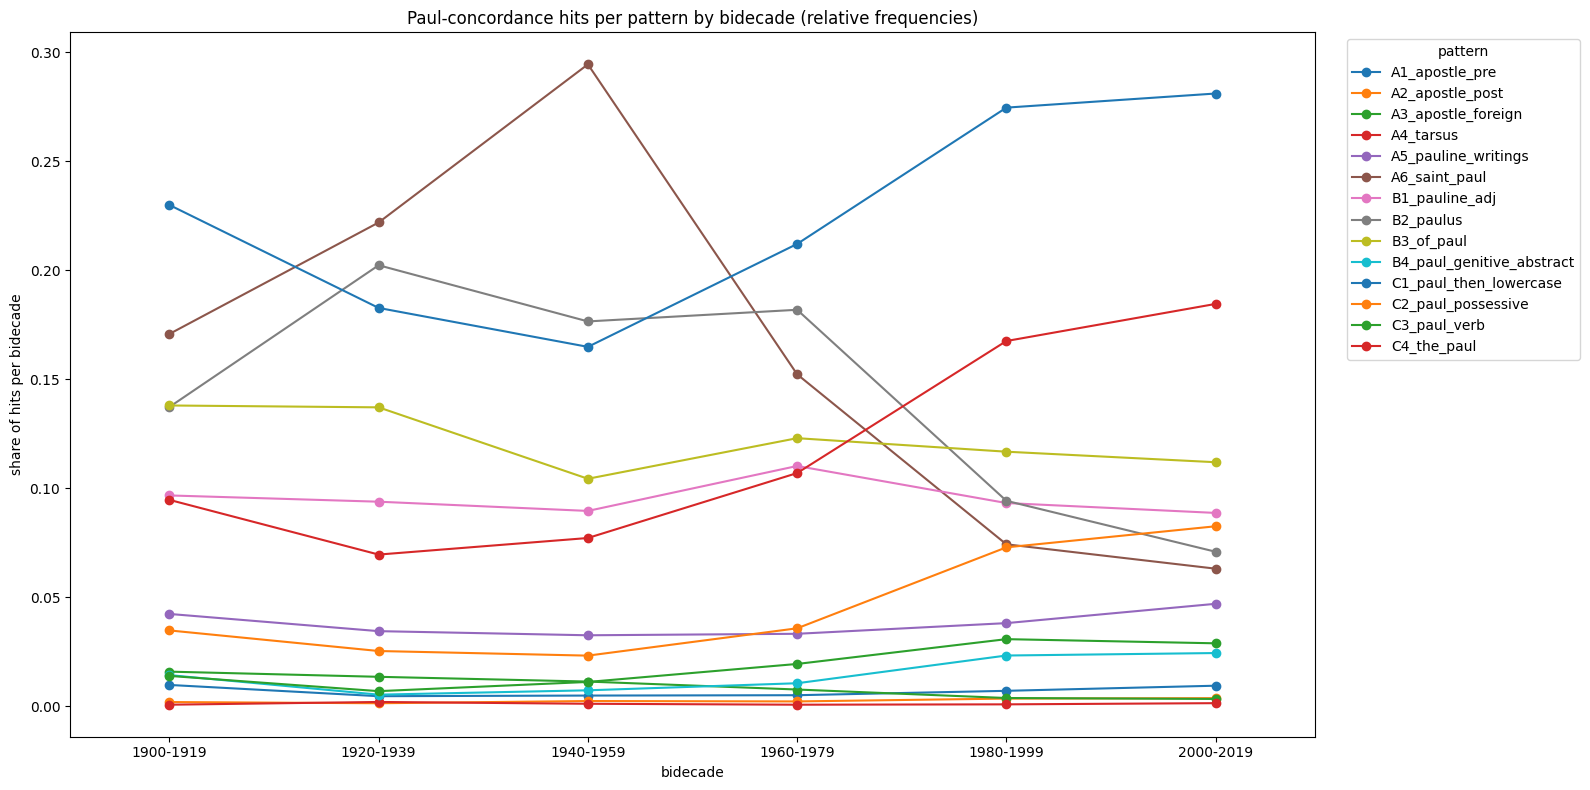

In [19]:
# relative frequency: each bidecade's patterns as a share of that bidecade's total
# absolute counts: bidecade × pattern (rows = bidecade, cols = pattern)
pattern_by_bidecade = (
    hits.groupby(["bidecade", "pattern"])
        .size()
        .unstack(fill_value=0)
        .sort_index()          # "1920-1939" … "2020-2039" sorts chronologically
)

# focus exclusively on bidecades between 1900 and 2020
pattern_by_bidecade = pattern_by_bidecade.loc[
    (pattern_by_bidecade.index.get_level_values(0).str[:4].astype(int) >= 1900)
    & (pattern_by_bidecade.index.get_level_values(0).str[:4].astype(int) < 2020)
]

# relative frequency: each bidecade's patterns as a share of that bidecade's total
pattern_rel = pattern_by_bidecade.div(pattern_by_bidecade.sum(axis=1), axis=0)

# midpoint year of each bidecade, e.g. "1980-1999" -> 1989.5
midpoints = {bd: (int(bd[:4]) + int(bd[5:])) / 2 for bd in pattern_rel.index}
x = [midpoints[bd] for bd in pattern_rel.index]

fig_pat, ax_pat = plt.subplots(figsize=(16, 8))
for pattern in pattern_rel.columns:
    ax_pat.plot(x, pattern_rel[pattern].values,
                marker="o", linewidth=1.5, label=pattern)

# ticks only at the bidecade midpoints
ax_pat.set_xticks(x)
ax_pat.set_xticklabels(pattern_rel.index)

# extend x-limits by half a bidecade on each side so every dot sits centred in its band
first_start = int(pattern_rel.index[0][:4])
last_end    = int(pattern_rel.index[-1][5:])
ax_pat.set_xlim(first_start, last_end)

ax_pat.set_xlabel("bidecade")
ax_pat.set_ylabel("share of hits per bidecade")
ax_pat.set_title("Paul-concordance hits per pattern by bidecade (relative frequencies)")
ax_pat.legend(title="pattern", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
fig.savefig("../figures/patterns_by_bidecade.png")

# Concordance tokens explorations

In [21]:
conc_words_flat = [t for c in hits["kwic_tokens"] for t in c]
len(conc_words_flat)

14018855

In [22]:
nltk.FreqDist(conc_words_flat).most_common(50)

[('the', 568008),
 ('of', 393901),
 ('in', 273895),
 ('and', 231785),
 ('to', 222464),
 ('a', 151193),
 ('is', 133775),
 ('that', 125235),
 ('de', 124164),
 ('s', 108510),
 ('as', 79786),
 ('1', 76214),
 ('Paul', 73577),
 ('The', 66893),
 ('his', 66205),
 ('la', 64937),
 ('der', 59034),
 ('et', 55296),
 ('not', 54643),
 ('for', 54046),
 ('2', 51734),
 ('on', 51084),
 ('die', 50895),
 ('l', 50844),
 ('with', 49892),
 ('by', 48533),
 ('des', 47812),
 ('this', 46709),
 ('und', 46210),
 ('was', 45752),
 ('it', 45422),
 ('be', 44434),
 ('he', 42696),
 ('le', 39976),
 ('à', 37655),
 ('an', 36876),
 ('3', 36466),
 ('from', 36402),
 ('which', 35556),
 ('I', 34325),
 ('est', 31085),
 ('are', 30952),
 ('In', 30452),
 ('Christ', 30144),
 ('4', 29128),
 ('have', 28829),
 ('A', 28376),
 ('les', 28351),
 ('que', 28176),
 ('en', 27378)]

In [23]:
bool({"paul", "peter", "jewish"} & { "judaism", "jewish"})

True

In [24]:
def check_overlap(kwic_tokens, checked_set):
    kwic_tokens = [t.lower() for t in kwic_tokens]  # convert to lowercase for case-insensitive matching
    return bool(set(kwic_tokens) & checked_set)
    

In [25]:
jewish_terms = {"jew", "jews", "judaism", "jewish", "judentum", "jude", "judean", "judeans"}

In [26]:
def get_overlap(checked_set):
    hits_overlapped = hits["kwic_tokens"].apply(lambda tokens: check_overlap(tokens, jewish_terms))
    return hits_overlapped

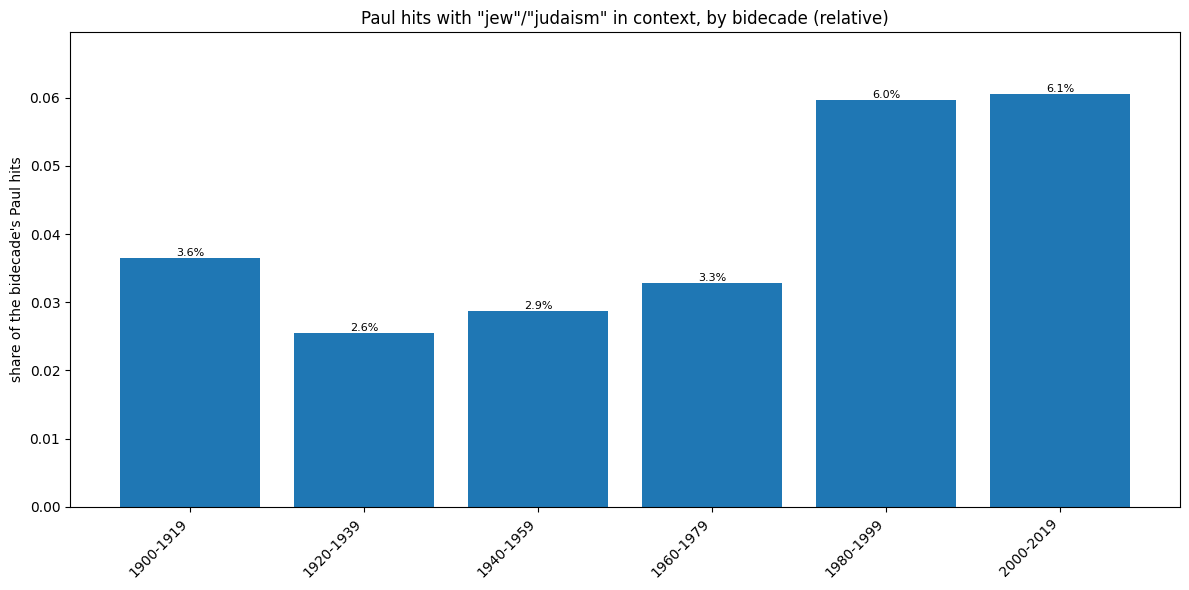

In [27]:
jewish_terms = {"jew", "jews", "judaism", "jewish", "judentum", "jude", "judean", "judeans"}

# boolean flag per hit: does the KWIC context mention anything Jewish?
hits["kwic_jewish"] = hits["kwic_tokens"].apply(lambda tokens: check_overlap(tokens, jewish_terms))

# hits with a Jewish term in the window, per bidecade, plus the share of all hits in that bidecade
jewish_by_bidecade = (
    hits.groupby("bidecade")["kwic_jewish"]
        .agg(hits_jewish="sum", hits_total="size")
        .assign(share=lambda d: d["hits_jewish"] / d["hits_total"])
)

jewish_by_bidecade = jewish_by_bidecade.loc[
    (jewish_by_bidecade.index.get_level_values(0).str[:4].astype(int) >= 1900)
    & (jewish_by_bidecade.index.get_level_values(0).str[:4].astype(int) < 2020)
]

xpos = range(len(jewish_by_bidecade))

fig_jew, ax_jew = plt.subplots(figsize=(12, 6))
ax_jew.bar(xpos, jewish_by_bidecade["share"])
ax.set_xlim((2,4))
ax_jew.set_xticks(list(xpos))
ax_jew.set_xticklabels(jewish_by_bidecade.index, rotation=45, ha="right")
ax_jew.set_ylabel("share of the bidecade's Paul hits")
ax_jew.set_title('Paul hits with "jew"/"judaism" in context, by bidecade (relative)')
for i, v in enumerate(jewish_by_bidecade["share"]):
    ax_jew.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=8)
ax_jew.set_ylim(0, jewish_by_bidecade["share"].max() * 1.15)

plt.tight_layout()
plt.show()



# Tokens lemmatized

In [28]:
import spacy

# download once if the model isn't cached yet (uncomment the first time)
# !python -m spacy download en_core_web_md
# !python -m spacy download fr_core_news_md
# python -m spacy download de_core_news_md

nlp_eng = spacy.load("en_core_web_md")
nlp_fra = spacy.load("fr_core_news_md")
nlp_ger = spacy.load("de_core_news_md")

In [29]:
hits["language"].value_counts()

language
eng    280919
fre     66059
ger     59899
en       8045
lat      3949
ita      2632
dut      2349
por      1311
spa      1252
heb       269
pol       130
afr        65
gle        14
cos         5
pt          4
es          2
gre         2
ara         1
Name: count, dtype: int64

In [30]:
hits[hits["language"]=="en"].sample(10)

,item_id,year,bidecade,journal,language,tier,pattern,flags,char_start,char_end,match,kwic_left,kwic_right,sentence,doc_len,kwic_tokens,journal-cat,journal-discipline,journal-confession,kwic_jewish
131105,4fd84fee-b392-3a54-b43b-efc49f0d35f2,2017,2000-2019,Journal of Biblical Literature,en,C,C4_the_paul,None,57134,57143,with Paul,…of God has been sent to the gentiles; they wi...,in Rome welcoming “all who came to him” (28:30...,After the Roman Jews offer a predictably mixed...,61992,"[of, God, has, been, sent, to, the, gentiles, ...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,False
188865,73345154-fa3d-3e41-a212-09ffd99a730a,2015,2000-2019,Journal of Biblical Literature,en,C,C4_the_paul,None,65106,65115,from Paul,…resurrection hovering before his eyes. But .....,"to Jesus.” See also Peder Borgen, “From Paul t...",But ... there was also an influence from Acts ...,66753,"[resurrection, hovering, before, his, eyes, Bu...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,False
252361,9920a6f5-72fe-309a-91e7-972d09dfcd36,2014,2000-2019,The Journal of Religion,en,C,C1_paul_then_lowercase,None,31544,31549,Paul,…to the status quo that has been interrupted.”...,draws the consequence that one can only begin ...,Thus the initial intervention is purely “of th...,64613,"[to, the, status, quo, that, has, been, interr...",Protestant+religion/culture,religion/culture,Protestant,False
199479,79619b7c-3d62-3f45-84c7-c82f6db13afe,2016,2000-2019,Journal of Biblical Literature,en,C,C4_the_paul,None,59411,59419,for Paul,…owes a debt to early Jewish traditions that i...,"is that, while ὁ νόμος remains distinctly pr...","The difference for Paul is that, while ὁ νόμ...",69731,"[owes, a, debt, to, early, Jewish, traditions,...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,True
24034,0e7e5601-d390-3f60-806e-ac3a65490373,2018,2000-2019,Journal of Feminist Studies in Religion,en,C,C1_paul_then_lowercase,None,33896,33901,Paul,"…plural, it normally serves as metonymy for pe...",tends to use the Greek word soma as a distinct...,Two authoritative Greek lexicons define the Gr...,52411,"[plural, it, normally, serves, as, metonymy, f...",Independent/non-denominational+religion/culture,religion/culture,Independent/non-denominational,False
295873,b2a97db9-cb37-3d10-bca7-bdd6babd323b,2014,2000-2019,Journal of Biblical Literature,en,C,C1_paul_then_lowercase,None,57840,57845,Paul,…and pronouns. All compete together for the vi...,"is not so much a competitor as a trainer, one ...",Stephan Joubert suggests that here Paul is not...,90364,"[and, pronouns, All, compete, together, for, t...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,False
225298,888e83b8-ef84-388b-82a5-bca8e3aba0ea,2017,2000-2019,Journal of Biblical Literature,en,C,C4_the_paul,citation_apparatus,26238,26245,by Paul,…is the most natural understanding of the stat...,requires a substantial clarification in the se...,To construe it as a statement by Paul requires...,51941,"[is, the, most, natural, understanding, of, th...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,False
7201,044f3026-3071-3abb-87d0-d5ea8023947e,2015,2000-2019,Journal of Biblical Literature,en,C,C3_paul_verb,None,38644,38655,Paul writes,…living body to a resurrected body. The πνεῦμ...,", the only resurrected body is Christ’s body. ...","At the time Paul writes, the only resurrected ...",49532,"[living, body, to, a, resurrected, body, The, ...",Protestant+biblical/early Christian,biblical/early Christian,Protestant,False
234474,8e5e6fc3-9f17-3293-8fb1-892414ea6699,2015,2000-2019,History of Religions,en,B,B3_of_paul,None,5896,5903,of Paul,…primarily on William James’s The Varieties of...,"and fit, according to Nock, only the religious...",This conception of conversion was based primar...,58062,"[primarily, on, William, James, s, The, Variet...",NaN,NaN,NaN,False
380924,e37d758a-b198-3bec-9afa-f2ad8a5d5050,

In [39]:

def nlp_kwic(row):
    left = str(row["kwic_left"])
    match = str(row["match"])
    right = str(row["kwic_right"])
    kwic_string = " ".join([left, match, right])

    # character span of `match` inside kwic_string
    match_start = len(left) + 1
    match_end = match_start + len(match)

    if row["language"] in ["en", "eng"]:
            doc = nlp_eng(kwic_string)
    elif row["language"] in ["fr", "fra"]:
            doc = nlp_fra(kwic_string)
    elif row["language"] in ["de", "ger"]:
            doc = nlp_ger(kwic_string)
    else:
            doc = nlp_eng("")  # fallback to English if language is unknown

    sents = []
    for sent in doc.sents:
            sent_tokens = [
                (
                    token.text,
                    token.lemma_,
                    token.pos_,
                    token.tag_,
                    token.dep_,
                    token.is_alpha,
                    token.is_stop,
                    # True if this token overlaps the match span
                    token.idx < match_end and (token.idx + len(token.text)) > match_start,
                )
                for token in sent
            ]
            sents.append(sent_tokens)
    return sents


In [40]:
docs = hits.sample(100).apply(nlp_kwic, axis=1)

In [54]:
nlp_tokens = docs.tolist()[55]
tokens_flat = [token for sent_data in nlp_tokens for token in sent_data]
[t for t in tokens_flat if t[-1]]

[('Pauline', 'Pauline', 'PROPN', 'NNP', 'compound', True, False, True)]

In [55]:
%%time
hits["kwic_nlp"] = hits.apply(nlp_kwic, axis=1)

CPU times: user 33min 33s, sys: 3.25 s, total: 33min 37s
Wall time: 33min 37s


In [56]:
# `hits` is a concrete pandas.DataFrame — no abstract methods exist to implement.
# The only pyarrow-problematic column is `kwic_nlp` (list[list[tuple]]); turn each
# token tuple into a named dict so pyarrow can store it as list<list<struct>>.
token_fields = ["text", "lemma", "pos", "tag", "dep", "is_alpha", "is_stop"]

hits["kwic_nlp"] = hits["kwic_nlp"].apply(
    lambda sents: [
        [dict(zip(token_fields, tok)) for tok in sent]
        for sent in sents
    ]
)

In [57]:
hits.to_parquet(
    "../data/large_files/paul_scan/hits_nlp.parquet",
    engine="pyarrow",
    index=False,
)